# XGBoost Regression Example: Shallow Trees Fitting Complex Patterns

This notebook demonstrates how XGBoost can use shallow decision trees (depth 1-2) to fit complex regression patterns through boosting. We'll create synthetic data with non-linear patterns and show how boosting improves predictions step by step.

Our goal here is to illustrate the mechanics with a simple, clean example, where we can see explicitly how boosting simple learners (shallow trees, in this case), successively refines until we have enough complexity to fit the data.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("Libraries imported successfully!")


Libraries imported successfully!


## 1. Generate Synthetic Regression Data

We'll create a complex non-linear function that would be difficult for a single shallow tree to fit well, but perfect for demonstrating boosting.


Training samples: 160
Test samples: 40


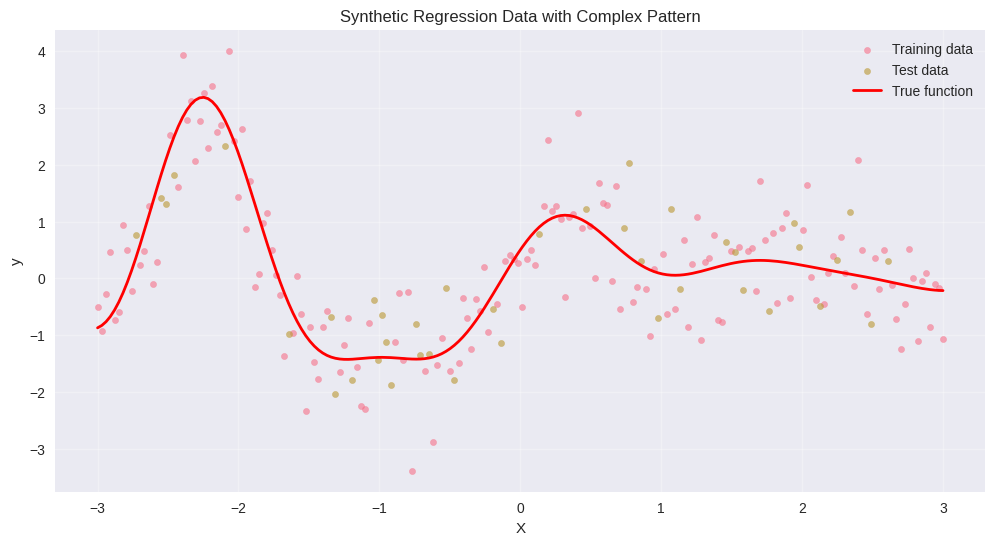

In [ ]:
def generate_complex_function(x):
    """Generate a complex non-linear function with multiple patterns"""
    return (np.sin(x * 2) * np.exp(-x/3) +
            np.cos(x * 3) * 0.5 +
            np.sin(x * 5) * 0.3 * np.exp(-x/2) +
            x * 0.1)

# Generate training data
np.random.seed(42)
n_samples = 200
X = np.linspace(-3, 3, n_samples).reshape(-1, 1)
y_true = generate_complex_function(X.flatten())
y = y_true + np.random.normal(0, 0.75, n_samples)  # Add noise

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")

# Plot the data
plt.figure(figsize=(12, 6))
plt.scatter(X_train, y_train, alpha=0.6, label='Training data', s=20)
plt.scatter(X_test, y_test, alpha=0.6, label='Test data', s=20)
plt.plot(X.flatten(), y_true, 'r-', linewidth=2, label='True function')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Synthetic Regression Data with Complex Pattern')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 2. Single Decision Tree Baseline

Let's start with a single decision tree to see how it performs on this complex pattern.


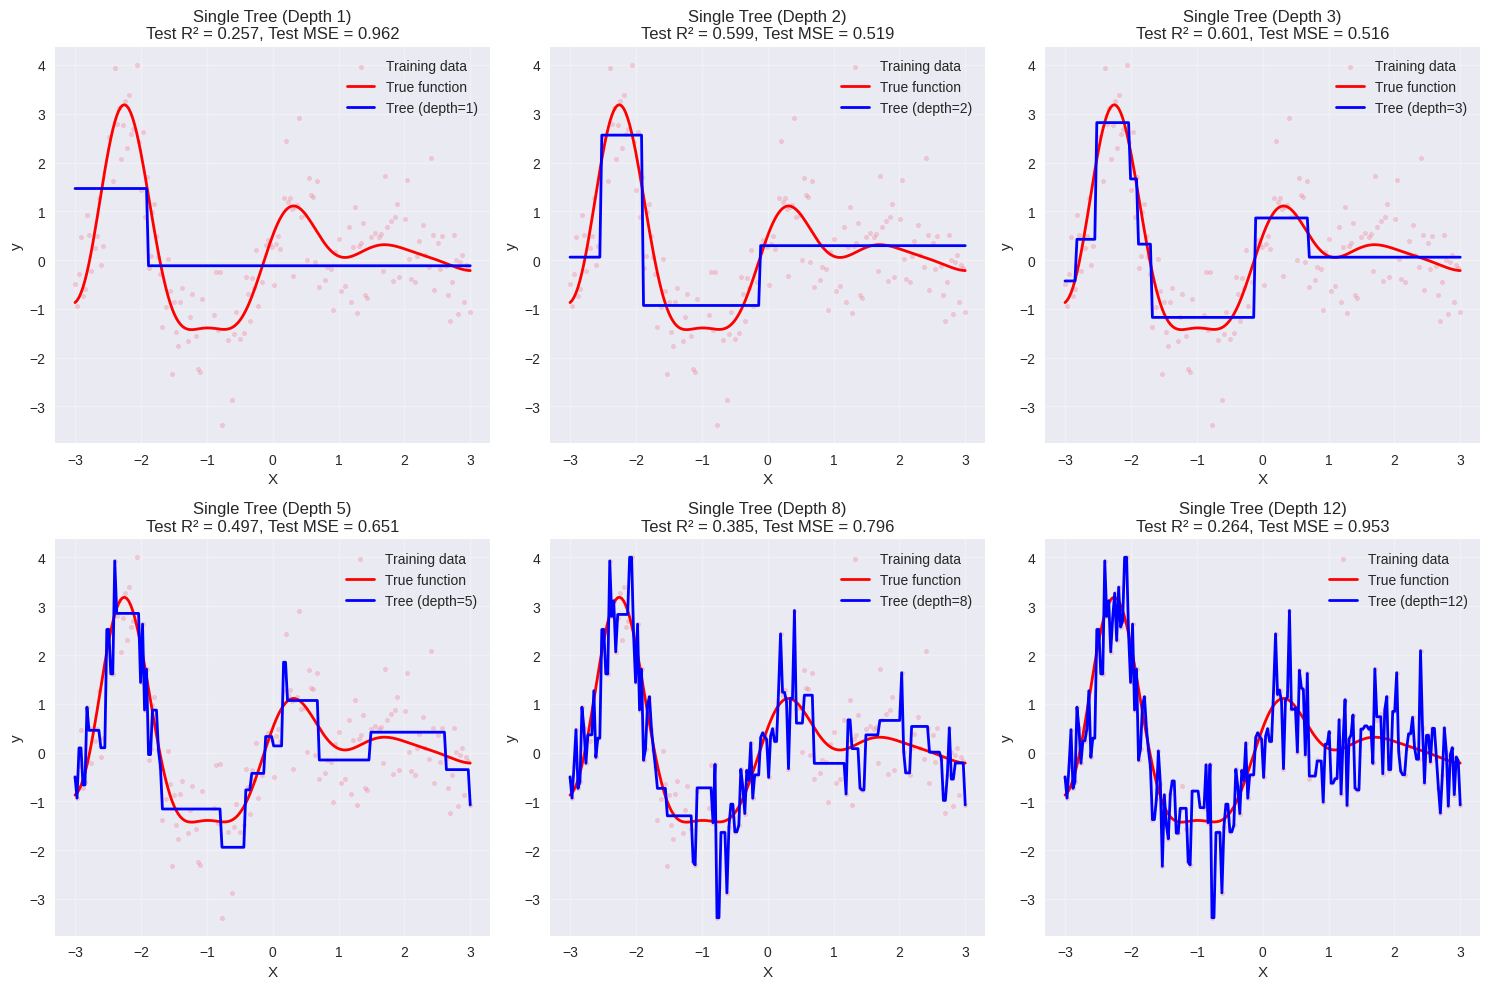


Single Tree Performance:
--------------------------------------------------
Depth 1: Train R² = 0.239, Test R² = 0.257
         Train MSE = 1.277, Test MSE = 0.962
Depth 2: Train R² = 0.583, Test R² = 0.599
         Train MSE = 0.700, Test MSE = 0.519
Depth 3: Train R² = 0.699, Test R² = 0.601
         Train MSE = 0.505, Test MSE = 0.516
Depth 5: Train R² = 0.805, Test R² = 0.497
         Train MSE = 0.327, Test MSE = 0.651
Depth 8: Train R² = 0.918, Test R² = 0.385
         Train MSE = 0.137, Test MSE = 0.796
Depth 12: Train R² = 0.999, Test R² = 0.264
         Train MSE = 0.002, Test MSE = 0.953


In [ ]:
# Single decision tree with different depths
depths = [1, 2, 3, 5, 8, 12]
tree_predictions = {}
tree_scores = {}

plt.figure(figsize=(15, 10))

for i, depth in enumerate(depths):
    # Train single tree
    tree = DecisionTreeRegressor(max_depth=depth, random_state=42)
    tree.fit(X_train, y_train)

    # Predictions
    y_pred_train = tree.predict(X_train)
    y_pred_test = tree.predict(X_test)

    # Store predictions
    tree_predictions[depth] = tree.predict(X)

    # Calculate scores
    train_mse = mean_squared_error(y_train, y_pred_train)
    test_mse = mean_squared_error(y_test, y_pred_test)
    train_r2 = r2_score(y_train, y_pred_train)
    test_r2 = r2_score(y_test, y_pred_test)

    tree_scores[depth] = {'train_mse': train_mse, 'test_mse': test_mse,
                         'train_r2': train_r2, 'test_r2': test_r2}

    # Plot
    plt.subplot(2, 3, i+1) # Changed from 2, 2, i+1 to 2, 3, i+1 to accommodate all 6 plots
    plt.scatter(X_train, y_train, alpha=0.3, s=10, label='Training data')
    plt.plot(X.flatten(), y_true, 'r-', linewidth=2, label='True function')
    plt.plot(X.flatten(), tree_predictions[depth], 'b-', linewidth=2, label=f'Tree (depth={depth})')
    plt.title(f'Single Tree (Depth {depth})\nTest R² = {test_r2:.3f}, Test MSE = {test_mse:.3f}')
    plt.xlabel('X')
    plt.ylabel('y')
    plt.legend()
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print scores
print("\nSingle Tree Performance:")
print("-" * 50)
for depth in depths:
    scores = tree_scores[depth]
    print(f"Depth {depth}: Train R² = {scores['train_r2']:.3f}, Test R² = {scores['test_r2']:.3f}")
    print(f"         Train MSE = {scores['train_mse']:.3f}, Test MSE = {scores['test_mse']:.3f}")


In [ ]:
# report best Test MSE from above
best_depth = min(depths, key=lambda d: tree_scores[d]['test_mse'])
print(f"Best Single Tree (depth={best_depth}) has the lowest Test MSE of {tree_scores[best_depth]['test_mse']:.4f}")

Best Single Tree (depth=3) has the lowest Test MSE of 0.5162


## 3. The Boosting Story: How Weak Learners Become Strong

### The Intuition Behind Boosting

Boosting is like having a team of specialists where each member focuses on the mistakes of the previous ones. Here's the story:

1. **The First Learner**: A simple model (like a shallow tree) makes predictions, but it's not very good - it makes mistakes.

2. **Learning from Mistakes**: The next learner doesn't just try to fit the original data. Instead, it focuses heavily on the examples that the first learner got wrong.

3. **Weighted Combination**: Each learner gets a "vote" in the final prediction, but some learners' votes count more than others based on how well they perform.

4. **Iterative Improvement**: This process continues - each new learner focuses on the remaining errors, and the ensemble gets better and better.

### Why This Works

- **Bias-Variance Tradeoff**: Individual weak learners have high bias (they're too simple) but low variance. By combining many of them, we reduce bias while keeping variance low.

- **Error Correction**: Each new learner corrects specific types of errors made by previous learners.

- **Adaptive Learning**: The algorithm automatically focuses on the hardest examples, making the ensemble more robust.

### The Mathematical Foundation

For regression, boosting minimizes the following objective at each step:

**Step 1**: Start with a simple model F₀(x) (often just the mean of y)

**Step 2**: For m = 1 to M (number of boosting rounds):
   - Calculate residuals: rᵢ = yᵢ - F_{m-1}(xᵢ)
   - Train a new weak learner h_m(x) to predict the residuals
   - Update the model: F_m(x) = F_{m-1}(x) + αₘ × h_m(x)
   - Where αₘ is the learning rate (step size)

**Final Prediction**: F_M(x) = F₀(x) + α₁h₁(x) + α₂h₂(x) + ... + αₘhₘ(x)

This is essentially **gradient descent in function space** - we're iteratively improving our function approximation by moving in the direction that reduces the loss function.


## 4. Manual Boosting Implementation

Now let's implement boosting manually to see how it works step by step. We'll use depth-2 trees as our weak learners and show how each iteration improves the predictions.


In [ ]:
# Manual Boosting Implementation
def manual_boosting(X_train, y_train, X_test, y_test, n_estimators=10, learning_rate=0.1, max_depth=2):
    """
    Manual implementation of gradient boosting for regression
    """
    # Initialize
    n_train = len(X_train)
    n_test = len(X_test)

    # Start with the mean of y as our initial prediction
    initial_prediction = np.mean(y_train)
    train_predictions = np.full(n_train, initial_prediction)
    test_predictions = np.full(n_test, initial_prediction)

    # Store results for each iteration
    trees = []
    train_errors = []
    test_errors = []
    train_r2_scores = []
    test_r2_scores = []

    print(f"Initial prediction (mean): {initial_prediction:.4f}")
    print(f"Initial Train MSE: {mean_squared_error(y_train, train_predictions):.4f}")
    print(f"Initial Test MSE: {mean_squared_error(y_test, test_predictions):.4f}")
    print("-" * 60)

    for i in range(n_estimators):
        # Calculate residuals (negative gradients for MSE loss)
        train_residuals = y_train - train_predictions
        test_residuals = y_test - test_predictions

        # Fit a tree to the residuals
        tree = DecisionTreeRegressor(max_depth=max_depth, random_state=42)
        tree.fit(X_train, train_residuals)

        # Make predictions on residuals
        train_residual_pred = tree.predict(X_train)
        test_residual_pred = tree.predict(X_test)

        # Update predictions with learning rate
        train_predictions += learning_rate * train_residual_pred
        test_predictions += learning_rate * test_residual_pred

        # Calculate metrics
        train_mse = mean_squared_error(y_train, train_predictions)
        test_mse = mean_squared_error(y_test, test_predictions)
        train_r2 = r2_score(y_train, train_predictions)
        test_r2 = r2_score(y_test, test_predictions)

        # Store results
        trees.append(tree)
        train_errors.append(train_mse)
        test_errors.append(test_mse)
        train_r2_scores.append(train_r2)
        test_r2_scores.append(test_r2)

        print(f"Iteration {i+1:2d}: Train MSE = {train_mse:.4f}, Test MSE = {test_mse:.4f}")
        print(f"           Train R² = {train_r2:.4f}, Test R² = {test_r2:.4f}")

    return {
        'trees': trees,
        'train_predictions': train_predictions,
        'test_predictions': test_predictions,
        'train_errors': train_errors,
        'test_errors': test_errors,
        'train_r2_scores': train_r2_scores,
        'test_r2_scores': test_r2_scores,
        'initial_prediction': initial_prediction
    }

# Run manual boosting
print("Manual Boosting with Depth-2 Trees")
print("=" * 60)
manual_results = manual_boosting(X_train, y_train, X_test, y_test, n_estimators=20, learning_rate=0.1)


Manual Boosting with Depth-2 Trees
Initial prediction (mean): 0.2013
Initial Train MSE: 1.6777
Initial Test MSE: 1.3652
------------------------------------------------------------
Iteration  1: Train MSE = 1.4920, Test MSE = 1.1964
           Train R² = 0.1107, Test R² = 0.0760
Iteration  2: Train MSE = 1.3400, Test MSE = 1.0535
           Train R² = 0.2013, Test R² = 0.1864
Iteration  3: Train MSE = 1.2130, Test MSE = 0.9415
           Train R² = 0.2770, Test R² = 0.2729
Iteration  4: Train MSE = 1.1092, Test MSE = 0.8472
           Train R² = 0.3389, Test R² = 0.3457
Iteration  5: Train MSE = 1.0222, Test MSE = 0.7735
           Train R² = 0.3907, Test R² = 0.4026
Iteration  6: Train MSE = 0.9493, Test MSE = 0.7157
           Train R² = 0.4342, Test R² = 0.4472
Iteration  7: Train MSE = 0.8867, Test MSE = 0.6608
           Train R² = 0.4715, Test R² = 0.4897
Iteration  8: Train MSE = 0.8358, Test MSE = 0.6238
           Train R² = 0.5018, Test R² = 0.5182
Iteration  9: Train MSE = 0

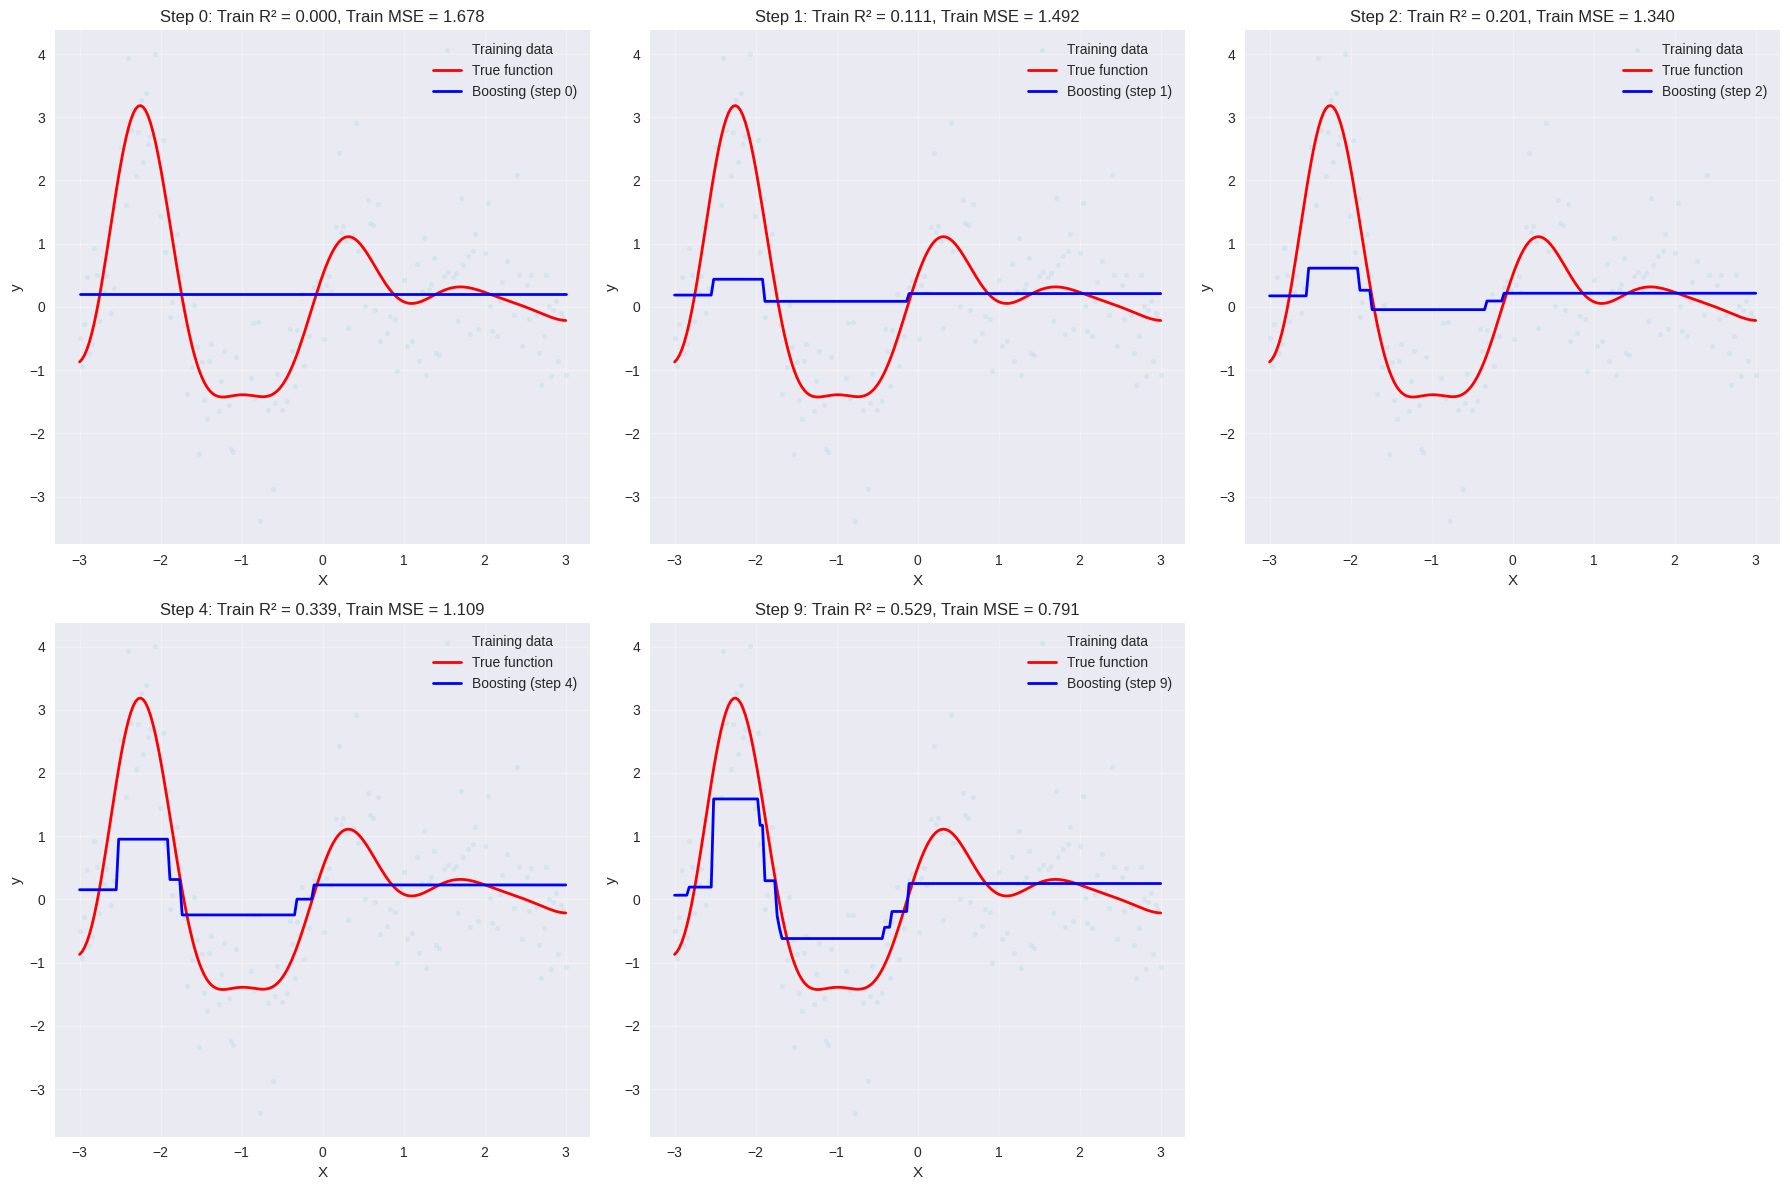

In [ ]:
# Visualize the boosting process step by step
def plot_boosting_steps(X, y_true, X_train, y_train, manual_results, steps_to_show=[0, 1, 2, 4, 9]):
    """
    Plot the boosting process at different iterations
    """
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()

    # Calculate predictions for each step
    predictions_at_steps = {}

    for step in steps_to_show:
        if step == 0:
            # Initial prediction (mean)
            pred = np.full(len(X), manual_results['initial_prediction'])
        else:
            # Cumulative prediction up to this step
            pred = np.full(len(X), manual_results['initial_prediction'])
            for i in range(step):
                pred += 0.1 * manual_results['trees'][i].predict(X)
        predictions_at_steps[step] = pred

    # Plot each step
    for i, step in enumerate(steps_to_show):
        ax = axes[i]

        # Plot data
        ax.scatter(X_train, y_train, alpha=0.3, s=10, label='Training data', color='lightblue')
        ax.plot(X.flatten(), y_true, 'r-', linewidth=2, label='True function')
        ax.plot(X.flatten(), predictions_at_steps[step], 'b-', linewidth=2,
                label=f'Boosting (step {step})')

        # Get metrics for this step
        if step == 0:
            train_mse = mean_squared_error(y_train, np.full(len(y_train), manual_results['initial_prediction']))
            train_r2 = r2_score(y_train, np.full(len(y_train), manual_results['initial_prediction']))
        else:
            train_mse = manual_results['train_errors'][step-1]
            train_r2 = manual_results['train_r2_scores'][step-1]

        ax.set_title(f'Step {step}: Train R² = {train_r2:.3f}, Train MSE = {train_mse:.3f}')
        ax.set_xlabel('X')
        ax.set_ylabel('y')
        ax.legend()
        ax.grid(True, alpha=0.3)

    # Remove the last subplot if not needed
    if len(steps_to_show) < 6:
        axes[-1].remove()

    plt.tight_layout()
    plt.show()

# Plot the boosting progression
plot_boosting_steps(X, y_true, X_train, y_train, manual_results)


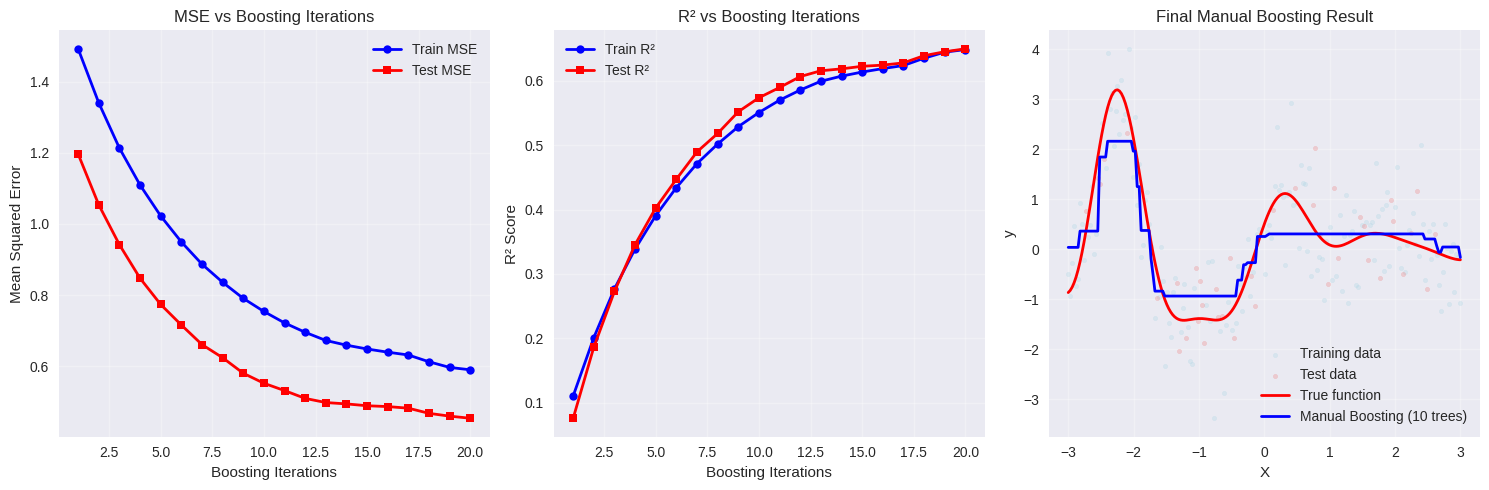


Final Manual Boosting Results:
Final Train R²: 0.6484
Final Test R²: 0.6496
Final Train MSE: 0.5898
Final Test MSE: 0.4537

Comparison with Single Depth-2 Tree:
Single Tree Test R²: 0.5995
Manual Boosting Test R²: 0.6496
Improvement in R²: 0.0501
Single Tree Test MSE: 0.5186
Manual Boosting Test MSE: 0.4537
Improvement in MSE: 0.0649


In [ ]:
# Plot the learning curves
plt.figure(figsize=(15, 5))

# Plot 1: MSE over iterations
plt.subplot(1, 3, 1)
iterations = range(1, len(manual_results['train_errors']) + 1)
plt.plot(iterations, manual_results['train_errors'], 'b-o', label='Train MSE', linewidth=2, markersize=6)
plt.plot(iterations, manual_results['test_errors'], 'r-s', label='Test MSE', linewidth=2, markersize=6)
plt.xlabel('Boosting Iterations')
plt.ylabel('Mean Squared Error')
plt.title('MSE vs Boosting Iterations')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: R² over iterations
plt.subplot(1, 3, 2)
plt.plot(iterations, manual_results['train_r2_scores'], 'b-o', label='Train R²', linewidth=2, markersize=6)
plt.plot(iterations, manual_results['test_r2_scores'], 'r-s', label='Test R²', linewidth=2, markersize=6)
plt.xlabel('Boosting Iterations')
plt.ylabel('R² Score')
plt.title('R² vs Boosting Iterations')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 3: Final comparison - need to generate predictions for the full X range
plt.subplot(1, 3, 3)
plt.scatter(X_train, y_train, alpha=0.3, s=10, label='Training data', color='lightblue')
plt.scatter(X_test, y_test, alpha=0.3, s=10, label='Test data', color='lightcoral')
plt.plot(X.flatten(), y_true, 'r-', linewidth=2, label='True function')

# Generate predictions for the full X range using our manual boosting model
full_predictions = np.full(len(X), manual_results['initial_prediction'])
for tree in manual_results['trees']:
    full_predictions += 0.1 * tree.predict(X)

plt.plot(X.flatten(), full_predictions, 'b-', linewidth=2, label='Manual Boosting (10 trees)')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Final Manual Boosting Result')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print final comparison
print("\nFinal Manual Boosting Results:")
print("=" * 50)
print(f"Final Train R²: {manual_results['train_r2_scores'][-1]:.4f}")
print(f"Final Test R²: {manual_results['test_r2_scores'][-1]:.4f}")
print(f"Final Train MSE: {manual_results['train_errors'][-1]:.4f}")
print(f"Final Test MSE: {manual_results['test_errors'][-1]:.4f}")

# Compare with single depth-2 tree
single_tree_r2 = tree_scores[2]['test_r2']
single_tree_mse = tree_scores[2]['test_mse']
print(f"\nComparison with Single Depth-2 Tree:")
print(f"Single Tree Test R²: {single_tree_r2:.4f}")
print(f"Manual Boosting Test R²: {manual_results['test_r2_scores'][-1]:.4f}")
print(f"Improvement in R²: {manual_results['test_r2_scores'][-1] - single_tree_r2:.4f}")
print(f"Single Tree Test MSE: {single_tree_mse:.4f}")
print(f"Manual Boosting Test MSE: {manual_results['test_errors'][-1]:.4f}")
print(f"Improvement in MSE: {single_tree_mse - manual_results['test_errors'][-1]:.4f}")


## 5. XGBoost Implementation

Now let's use XGBoost to do this automatically and compare with our manual implementation. XGBoost includes many optimizations and features that make it more efficient and robust.


XGBoost Implementation
XGBoost Results:
Train R²: 0.6402
Test R²: 0.6416
Train MSE: 0.6037
Test MSE: 0.4641

Comparison:
Manual Boosting Test R²: 0.6496
XGBoost Test R²: 0.6416
Difference: -0.0080


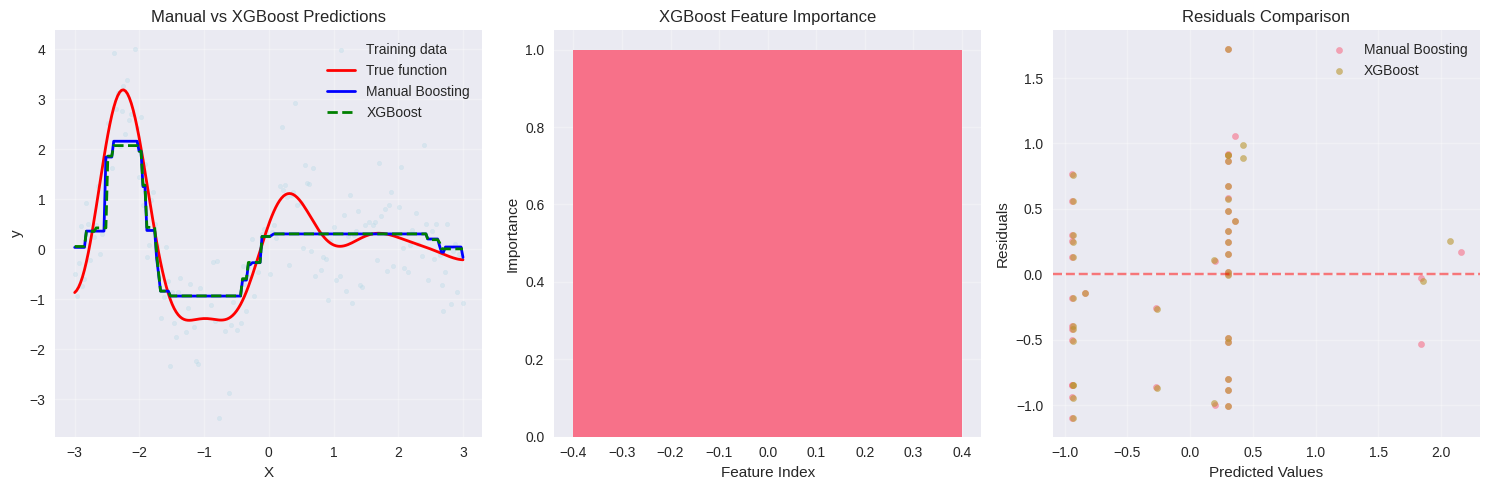

In [ ]:
# XGBoost Implementation
print("XGBoost Implementation")
print("=" * 60)

# Train XGBoost with similar parameters to our manual implementation
xgb_model = xgb.XGBRegressor(
    n_estimators=20,           # Same number of trees as manual
    max_depth=2,               # Same depth as manual
    learning_rate=0.1,         # Same learning rate as manual
    random_state=42,
    verbosity=0                # Suppress output
)

# Train the model
xgb_model.fit(X_train, y_train)

# Make predictions
xgb_train_pred = xgb_model.predict(X_train)
xgb_test_pred = xgb_model.predict(X_test)

# Calculate metrics
xgb_train_mse = mean_squared_error(y_train, xgb_train_pred)
xgb_test_mse = mean_squared_error(y_test, xgb_test_pred)
xgb_train_r2 = r2_score(y_train, xgb_train_pred)
xgb_test_r2 = r2_score(y_test, xgb_test_pred)

print(f"XGBoost Results:")
print(f"Train R²: {xgb_train_r2:.4f}")
print(f"Test R²: {xgb_test_r2:.4f}")
print(f"Train MSE: {xgb_train_mse:.4f}")
print(f"Test MSE: {xgb_test_mse:.4f}")

# Compare with manual implementation
print(f"\nComparison:")
print(f"Manual Boosting Test R²: {manual_results['test_r2_scores'][-1]:.4f}")
print(f"XGBoost Test R²: {xgb_test_r2:.4f}")
print(f"Difference: {xgb_test_r2 - manual_results['test_r2_scores'][-1]:.4f}")

# Plot comparison
plt.figure(figsize=(15, 5))

# Plot 1: Manual vs XGBoost predictions
plt.subplot(1, 3, 1)
plt.scatter(X_train, y_train, alpha=0.3, s=10, label='Training data', color='lightblue')
plt.plot(X.flatten(), y_true, 'r-', linewidth=2, label='True function')

# Generate predictions for the full X range for both models
# Manual boosting predictions for full X range
manual_full_predictions = np.full(len(X), manual_results['initial_prediction'])
for tree in manual_results['trees']:
    manual_full_predictions += 0.1 * tree.predict(X)

# XGBoost predictions for full X range
xgb_full_predictions = xgb_model.predict(X)

plt.plot(X.flatten(), manual_full_predictions, 'b-', linewidth=2, label='Manual Boosting')
plt.plot(X.flatten(), xgb_full_predictions, 'g--', linewidth=2, label='XGBoost')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Manual vs XGBoost Predictions')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Feature importance (XGBoost)
plt.subplot(1, 3, 2)
feature_importance = xgb_model.feature_importances_
plt.bar(range(len(feature_importance)), feature_importance)
plt.xlabel('Feature Index')
plt.ylabel('Importance')
plt.title('XGBoost Feature Importance')
plt.grid(True, alpha=0.3)

# Plot 3: Residuals comparison
plt.subplot(1, 3, 3)
manual_residuals = y_test - manual_results['test_predictions']
xgb_residuals = y_test - xgb_test_pred
plt.scatter(manual_results['test_predictions'], manual_residuals, alpha=0.6, label='Manual Boosting', s=20)
plt.scatter(xgb_test_pred, xgb_residuals, alpha=0.6, label='XGBoost', s=20)
plt.axhline(y=0, color='r', linestyle='--', alpha=0.5)
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residuals Comparison')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



XGBoost with More Trees
XGBoost (100 trees) Results:
Train R²: 0.8110
Test R²: 0.6102
Train MSE: 0.3172
Test MSE: 0.5047

Full Comparison: Best Single Tree vs Manual Boosting vs XGBoost
Method                 Train R²   Test R²    Train MSE    Test MSE    
--------------------------------------------------------------------------------
Single Tree (depth=3)  0.6991     0.6013     0.5049       0.5162      
Manual Boosting (10)   0.6484     0.6496     0.5898       0.4537      
XGBoost (10 trees)     0.6402     0.6416     0.6037       0.4641      
XGBoost (100 trees)    0.8110     0.6102     0.3172       0.5047      

Best by Test R²: Manual Boosting (10) (R² = 0.6496)
Best by Test MSE: Manual Boosting (10) (MSE = 0.4537)


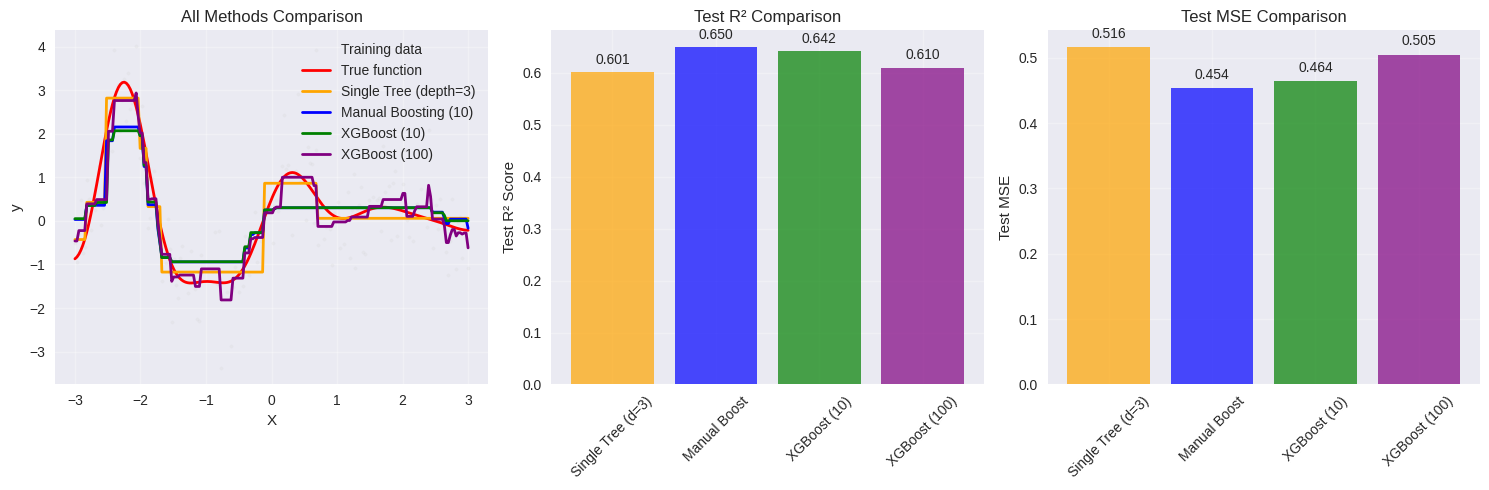

In [ ]:
# Let's also try XGBoost with more trees to see the full potential
print("\nXGBoost with More Trees")
print("=" * 60)

# Train XGBoost with more trees
xgb_model_large = xgb.XGBRegressor(
    n_estimators=100,          # More trees
    max_depth=2,               # Keep shallow trees
    learning_rate=0.1,         # Same learning rate
    random_state=42,
    verbosity=0
)

# Train the model
xgb_model_large.fit(X_train, y_train)

# Make predictions
xgb_large_train_pred = xgb_model_large.predict(X_train)
xgb_large_test_pred = xgb_model_large.predict(X_test)

# Calculate metrics
xgb_large_train_mse = mean_squared_error(y_train, xgb_large_train_pred)
xgb_large_test_mse = mean_squared_error(y_test, xgb_large_test_pred)
xgb_large_train_r2 = r2_score(y_train, xgb_large_train_pred)
xgb_large_test_r2 = r2_score(y_test, xgb_large_test_pred)

print(f"XGBoost (100 trees) Results:")
print(f"Train R²: {xgb_large_train_r2:.4f}")
print(f"Test R²: {xgb_large_test_r2:.4f}")
print(f"Train MSE: {xgb_large_train_mse:.4f}")
print(f"Test MSE: {xgb_large_test_mse:.4f}")

# Find best single tree (by test R²) among all depths we tried
best_depth = max(depths, key=lambda d: tree_scores[d]['test_r2'])
best_tree_train_r2 = tree_scores[best_depth]['train_r2']
best_tree_test_r2 = tree_scores[best_depth]['test_r2']
best_tree_train_mse = tree_scores[best_depth]['train_mse']
best_tree_test_mse = tree_scores[best_depth]['test_mse']
best_tree_label = f"Single Tree (depth={best_depth})"

# Full comparison: best single tree vs manual boosting vs XGBoost
print(f"\nFull Comparison: Best Single Tree vs Manual Boosting vs XGBoost")
print("=" * 80)
print(f"{'Method':<22} {'Train R²':<10} {'Test R²':<10} {'Train MSE':<12} {'Test MSE':<12}")
print("-" * 80)
print(f"{best_tree_label:<22} {best_tree_train_r2:<10.4f} {best_tree_test_r2:<10.4f} {best_tree_train_mse:<12.4f} {best_tree_test_mse:<12.4f}")
print(f"{'Manual Boosting (10)':<22} {manual_results['train_r2_scores'][-1]:<10.4f} {manual_results['test_r2_scores'][-1]:<10.4f} {manual_results['train_errors'][-1]:<12.4f} {manual_results['test_errors'][-1]:<12.4f}")
print(f"{'XGBoost (10 trees)':<22} {xgb_train_r2:<10.4f} {xgb_test_r2:<10.4f} {xgb_train_mse:<12.4f} {xgb_test_mse:<12.4f}")
print(f"{'XGBoost (100 trees)':<22} {xgb_large_train_r2:<10.4f} {xgb_large_test_r2:<10.4f} {xgb_large_train_mse:<12.4f} {xgb_large_test_mse:<12.4f}")

# Plot final comparison
plt.figure(figsize=(15, 5))

# Plot 1: All methods comparison
plt.subplot(1, 3, 1)
plt.scatter(X_train, y_train, alpha=0.2, s=5, label='Training data', color='lightgray')
plt.plot(X.flatten(), y_true, 'r-', linewidth=2, label='True function')
plt.plot(X.flatten(), tree_predictions[best_depth], 'orange', linewidth=2, label=best_tree_label)

# Generate predictions for the full X range for all models
# Manual boosting predictions for full X range
manual_full_predictions = np.full(len(X), manual_results['initial_prediction'])
for tree in manual_results['trees']:
    manual_full_predictions += 0.1 * tree.predict(X)

# XGBoost predictions for full X range
xgb_full_predictions = xgb_model.predict(X)
xgb_large_full_predictions = xgb_model_large.predict(X)

plt.plot(X.flatten(), manual_full_predictions, 'b-', linewidth=2, label='Manual Boosting (10)')
plt.plot(X.flatten(), xgb_full_predictions, 'g-', linewidth=2, label='XGBoost (10)')
plt.plot(X.flatten(), xgb_large_full_predictions, 'purple', linewidth=2, label='XGBoost (100)')
plt.xlabel('X')
plt.ylabel('y')
plt.title('All Methods Comparison')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Test R² comparison
plt.subplot(1, 3, 2)
methods = [f'Single Tree (d={best_depth})', 'Manual Boost', 'XGBoost (10)', 'XGBoost (100)']
test_r2_scores = [best_tree_test_r2, manual_results['test_r2_scores'][-1], xgb_test_r2, xgb_large_test_r2]
colors = ['orange', 'blue', 'green', 'purple']
bars = plt.bar(methods, test_r2_scores, color=colors, alpha=0.7)
plt.ylabel('Test R² Score')
plt.title('Test R² Comparison')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

# Add value labels on bars
for bar, score in zip(bars, test_r2_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{score:.3f}', ha='center', va='bottom')

# Plot 3: Test MSE comparison
plt.subplot(1, 3, 3)
test_mse_scores = [best_tree_test_mse, manual_results['test_errors'][-1], xgb_test_mse, xgb_large_test_mse]
bars = plt.bar(methods, test_mse_scores, color=colors, alpha=0.7)
plt.ylabel('Test MSE')
plt.title('Test MSE Comparison')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

# Add value labels on bars
for bar, score in zip(bars, test_mse_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{score:.3f}', ha='center', va='bottom')

# Summary: which method works best?
all_methods = [
    (best_tree_label, best_tree_test_r2, best_tree_test_mse),
    ('Manual Boosting (10)', manual_results['test_r2_scores'][-1], manual_results['test_errors'][-1]),
    ('XGBoost (10 trees)', xgb_test_r2, xgb_test_mse),
    ('XGBoost (100 trees)', xgb_large_test_r2, xgb_large_test_mse),
]
best_by_r2 = max(all_methods, key=lambda x: x[1])
best_by_mse = min(all_methods, key=lambda x: x[2])
print(f"\nBest by Test R²: {best_by_r2[0]} (R² = {best_by_r2[1]:.4f})")
print(f"Best by Test MSE: {best_by_mse[0]} (MSE = {best_by_mse[2]:.4f})")

plt.tight_layout()
plt.show()
